In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# In this version of the code, I will adapt the code slightly to be more aligned with the format of the FPAA, replacing voltage in for a gain term, replacing the individual components with cutoff frequencies, ensuring the filters are initialised such that the high pass band sits below the low pass band, and attempting to normalise gradient updates across parameters.

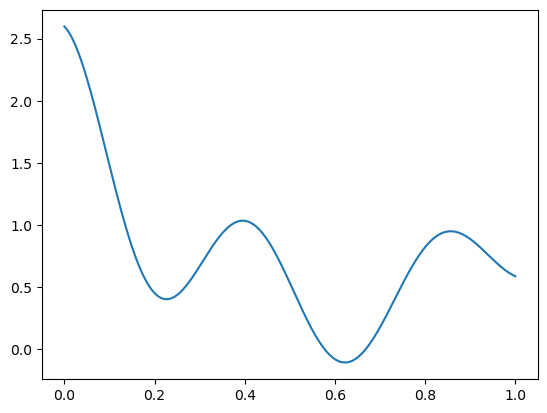

In [2]:
# Define the function to be fitted
def f(s):
    return 0.25*(torch.exp(1/(0.5*s+0.5))*torch.cos(5*s)*torch.cos(10*s)+3)

out = torch.zeros((1000))
s_in = torch.linspace(0, 1, 1000)
for i in range(1000):
    out[i] = f(s_in[i])
    
plt.figure()
plt.plot(s_in, out)
plt.show()

In [3]:
# Define a model to fit the filter parameters
class PhyKAN(nn.Module):
    def __init__(self, Nfilters):
        super().__init__()
        self.Nfilters = Nfilters
        self.filter_params = torch.rand((Nfilters, 3)).double()
        self.filter_params.requires_grad=True
        self.optim = torch.optim.Adam(params={self.filter_params}, lr=1e-2)
        self.lossfn = nn.MSELoss()
        
    # Redefined for torch & assuming trainable parameters
    def band_pass(self, freq):
        params = self.filter_params
        # For 'sensible' initialisation, we'd like parameters that make sense for gain, f_low, and f_high:
        # Set gain between +/- 3X
        gain = 6*(params[:, 0]-0.5)
        # Set cutoff frequencies between 1 and 10,000 Hz
        RC_low = 10**-torch.pi*(-1+4*params[:,1])
        RC_high = 10**-torch.pi*(-1+4*params[:,2])
        Hout = torch.zeros_like(freq)
        for i in range(self.Nfilters):
            Hout += gain[i]*torch.abs((2j*torch.pi*freq*RC_low[i]/(1+2j*torch.pi*freq*RC_low[i]))*(1/(1+2j*torch.pi*freq*RC_high[i])))
        return Hout
    
    def forward(self, Xin):
        # Normalise input of 0-1 to frequencies of 1-1000 Hz
        freq = 10**(1+3*Xin)
        # Pass through filter bank
        out = self.band_pass(freq)
        return out
    
    def train(self, Xin, Yin):
        self.optim.zero_grad()
        pred = self.forward(Xin)
        loss = self.lossfn(pred, Yin)
        loss.backward()
        self.optim.step()
        return(loss.item())

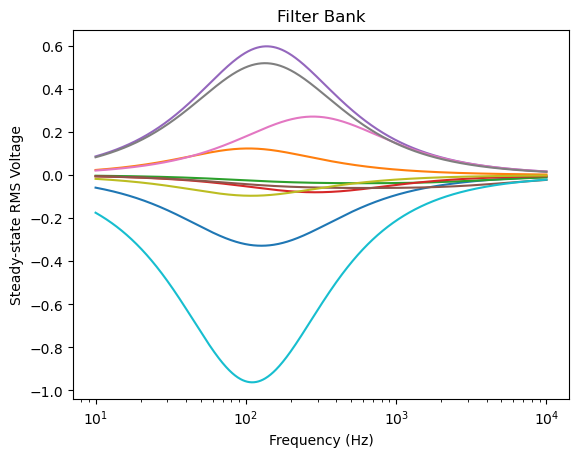

In [4]:
model = PhyKAN(10)
params = model.filter_params.cpu().detach().numpy()

freq = np.logspace(1, 4, 1000) # Logarithmic frequency spread between 1 and 1000 Hz
gain = 6*(params[:, 0]-0.5)
RC_low = 10**-torch.pi*(-3+5*params[:,1])
RC_high = 10**-torch.pi*(-3+5*params[:,2])
Hout = np.zeros((len(params), 1000))
for i in range(len(params)):
    Hout[i] = gain[i]*np.abs((2j*np.pi*freq*RC_low[i]/(1+2j*np.pi*freq*RC_low[i]))*(1/(1+2j*np.pi*freq*RC_high[i])))
plt.figure()
plt.semilogx(freq, Hout.T)
plt.title('Filter Bank')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Steady-state RMS Voltage')
plt.show()

4.288848400115967
0.000152095832163468
9.13687763386406e-05
0.00029246468329802155
3.203817686880939e-05
2.3989041437744163e-05
7.194410864030942e-05
2.429123742331285e-05
0.00022357988927979022
6.153784488560632e-05


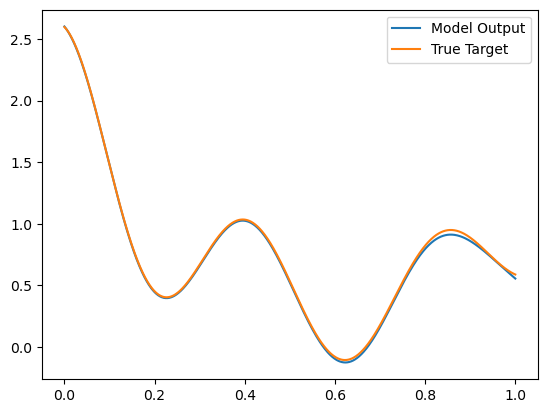

In [5]:
model = PhyKAN(5)

for i in range(100000):
    Xs = torch.rand(1000)
    Ys = f(Xs)
    loss = model.train(Xs, Ys)
    if i%10000 == 0:
        print(loss)
Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)

fig, ax = plt.subplots()

Xs = torch.linspace(0, 1, 1000)
Ys = model.forward(Xs)
Y_True = f(Xs)
line1, = ax.plot(Xs.cpu().detach().numpy().flatten(), Ys.cpu().detach().numpy().flatten(), label='Model Output')
line2, = ax.plot(Xs.cpu().detach().numpy().flatten(), Y_True.cpu().detach().numpy().flatten(), label='True Target')
plt.legend()
plt.show()


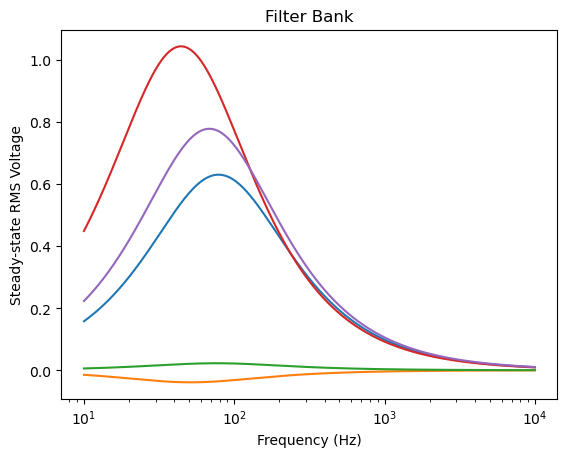

In [6]:
params = model.filter_params.sigmoid().cpu().detach().numpy()

freq = np.logspace(1, 4, 1000) # Logarithmic frequency spread between 1 and 1000 Hz
gain = 6*(params[:, 0]-0.5)
# Set cutoff frequencies between 1 and 10,000 Hz
RC_low = 10**-torch.pi*(5*params[:,1])
RC_high = 10**-torch.pi*(5*params[:,2])
Hout = np.zeros((len(params), 1000))
for i in range(len(params)):
    Hout[i] = gain[i]*np.abs((2j*np.pi*freq*RC_low[i]/(1+2j*np.pi*freq*RC_low[i]))*(1/(1+2j*np.pi*freq*RC_high[i])))
plt.figure()
plt.semilogx(freq, Hout.T)
plt.title('Filter Bank')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Steady-state RMS Voltage')
plt.show()